<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/2_finite_differece_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

# Finite difference method (FDM)

In general, to solve a PDE, we divide the space into a **lattice** and solve for the field $u(\vec{r})$ at each site of the lattice. We express derivatives in terms of finite differences in the values of $u$ at the lattice sites.

To derive the algorithm, we will use Poisson's and Laplace's equations as examples. We start by adding the Taylor expansions for $u(x,y)$:

* Derivate to the right:
\begin{align}
u(x+\Delta x,y) = u(x,y) + \dfrac{\partial u}{\partial x}\Delta x + \dfrac{1\,\partial^2 u}{2\partial x^2}(\Delta x)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x-\Delta x,y) = u(x,y) - \dfrac{\partial u}{\partial x}\Delta x + \dfrac{1\partial^2 u}{2\partial x^2}(\Delta x)^2 - \cdots\,.
\end{align}

If we add those expressions, the odd terms cancel out. Notice that we have eliminated the first derivative of the field.

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}\approx \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2}\,,
\end{align}

similarly for $y$ variable

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial y^2}\approx \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2}\,,
\end{align}

## 1. Poisson and Laplace's equation

The Poisson's equation is:

\begin{align}
\boxed{
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} = -4\pi\rho(x,y)} \,.
\end{align}

Let's expresed in finite diferences:

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} \approx& \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2} +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2}\\ \approx& -4\pi\rho(x,y) \,.
\end{align}

If we assume equal spacing in the grid $\Delta x = \Delta y =\Delta$, the algorithm takes a simple form:

\begin{align}
u(x+\Delta,y)+u(x-\Delta,y) +
u(x, y+\Delta)+u(x,y-\Delta)-4u(x,y) = -4\pi\rho(x,y)\Delta^2 \,.
\end{align}

To illustrate the method, we will use Laplace's equation in the context of the electric potential $u(x,y)$ ($\rho \to 0$). Electric charges, which are the sources of electric fields, enter indirectly through the values of the electric potential in certain regions of space.

\begin{align}
u(x,y) = \dfrac{1}{4} \bigg[u(x+\Delta,y)+u(x-\Delta,y) +
u(x, y+\Delta)+u(x,y-\Delta)\bigg]\,.
\end{align}

Let's consider the grid:


<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_3.png" alt="drawing" width="300"/>



To simplify the notation and use a compact, discrete notation, let $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, with ${i,j}=0,\cdots,N$. Laplace's equation can be written using finite differences as

\begin{align}
\boxed{
u_{i,j} = \dfrac{1}{4} \bigg[ u_{i+1,j}+u_{i-1,j} +
u_{i,j+1}+u_{i,j-1} \bigg]}\,
\end{align}


This equation expresses Laplace's equation. It states that the solution at the site $(i,j)$ is the average of the potential at its **four nearest neighbors**, as shown in the last figure, where $u_{i,j}=u(x_i,y_j)$. We must start with an initial condition (guess) for the potential and improve it by sweeping through the entire space, taking into account the nearest neighbors at each node in the grid. We repeat this process until the solution no longer changes beyond some specified level of precision (tolerance) or until convergence fails.

Does it always converge? How fast? We will see later. The relaxation methods converge slowly, although they are still faster than a Fourier series approach (*Computational physics with python- Manuel Paez, Landau book*).

## Relaxation

The basic form to interated the last equation is the **Jacobi method** in which the potential values are not change until an entire sweep of applying the last equation to each point is completed.

To accelerated the convergence, which in turn leads to less round-off error, we can use the technique, knows as **Gauss-Seidel (GS) method**. In terms of finite differences (see references):

\begin{align}
u_{i,j}^{\text{new}} = \dfrac{1}{4} \bigg[ u_{i+1,j}^{\text{old}}+u_{i-i,j}^{\text{new}} +
u_{i,j+1}^{\text{old}}+u_{i,j-1}^{\text{new}} \bigg]\,.
\end{align}

### Example 1: Solve the Laplace's equation

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_2.png" alt="drawing" width="300"/>

Let's use the **Jacobi method** to solve the **Laplace's equation** in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions

* u(x,0) = V(x) = f(x) $\to V_0$ = 100V
* u(0,y) = 0
* u(L,y) = 0
* u(x,L) = 0

Not continuous in the corners (y=0,L).

To solve the Laplace's equation we set the lenght plate $L=N\Delta = 100$ and $\Delta=1$. Also, we interact the algorithm $N_\text{iter}$ times.

 \begin{align}
 u(i,0) =\, & 100\,, \text{bottom} \hspace{1 cm} u(0,j) =\,0\,, \text{left} \\
 u(N,j) =\, & 0\,, \text{right} \hspace{1.7 cm} u(i,N) =\,0\,, \text{top}\,.
 \end{align}

### Laplace 2D: general rutine

In [2]:
#******  LaplaceLine.py  ********************************************
#  Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
def Laplace2D_FDM(V_ini,Niter):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'

  Nmax = V_ini.shape[0]
  V = V_ini.copy()

  for iter in range(Niter): # iterations over algorithm. Niter times
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

  return V

def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  #return grid
  return X,Y,Z

time (s)= 12.243149075


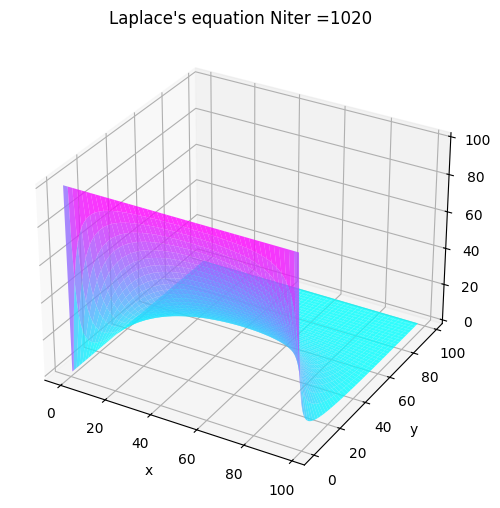

In [3]:
Nmax, Niter = 100, 1020

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100. # inerior a 100 V

# Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x

# propagate signal
start = tm.process_time() # Starting time counter for user
# Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start ) 

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

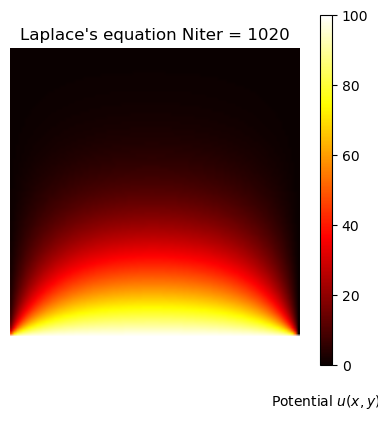

In [10]:
# Plot imshow
fig, ax = plt.subplots(figsize=(4,5) )
im = ax.imshow(Z.copy()[::-1,::-1], cmap="hot",interpolation="bilinear",) # rotate 180 degrees
ax.set_axis_off()
ax.set_title('Laplace\'s equation Niter = %.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

Behaviour with the number of iteration of the algoritm.

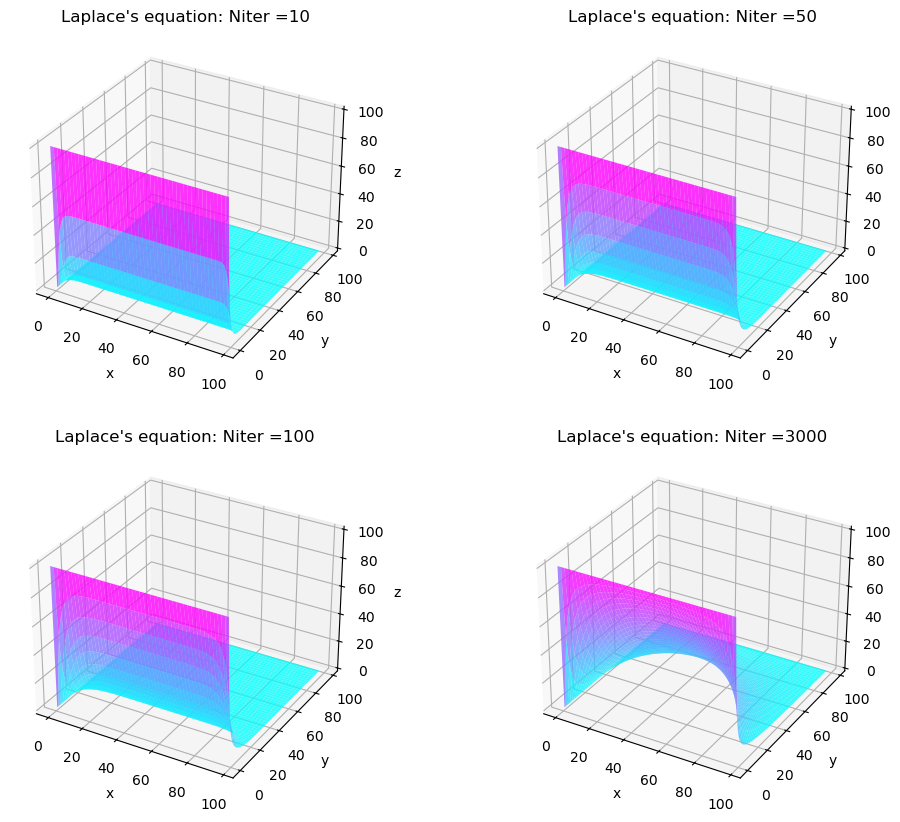

time (s)= 37.131873877000004


In [12]:
start = tm.process_time() #Starting time counter for user
fig, ax= plt.subplots(2,2, subplot_kw={'projection': '3d'},figsize=(12,10))
#************************************
Nmax, Niter = 100, 10
#Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
#Plot the field
ax[0,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,0].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_zlabel('z')
#************************************
Nmax, Niter = 100, 50
#Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
#Plot the field
ax[0,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,1].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_zlabel('z')
#************************************
Nmax, Niter = 100, 100
#Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
#Plot the field
ax[1,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,0].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('y')
ax[1,0].set_zlabel('z')
#************************************
Nmax, Niter = 100, 3000
#Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
#Plot the field
ax[1,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,1].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('y')
ax[1,1].set_zlabel('z')
#************************************

plt.show()
end = tm.process_time() #Finishing time counter for user
print('time (s)=' ,end-start ) # Storing result

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method** (laboratorio 3)


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

# Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** (laboratorio 3)

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [4]:
# let's construc you own rutine. My rutine looks like this
from capacitor import capacitor_df # my rutine

Niter = 300
V = capacitor_df(Niter)

<Figure size 1000x600 with 0 Axes>

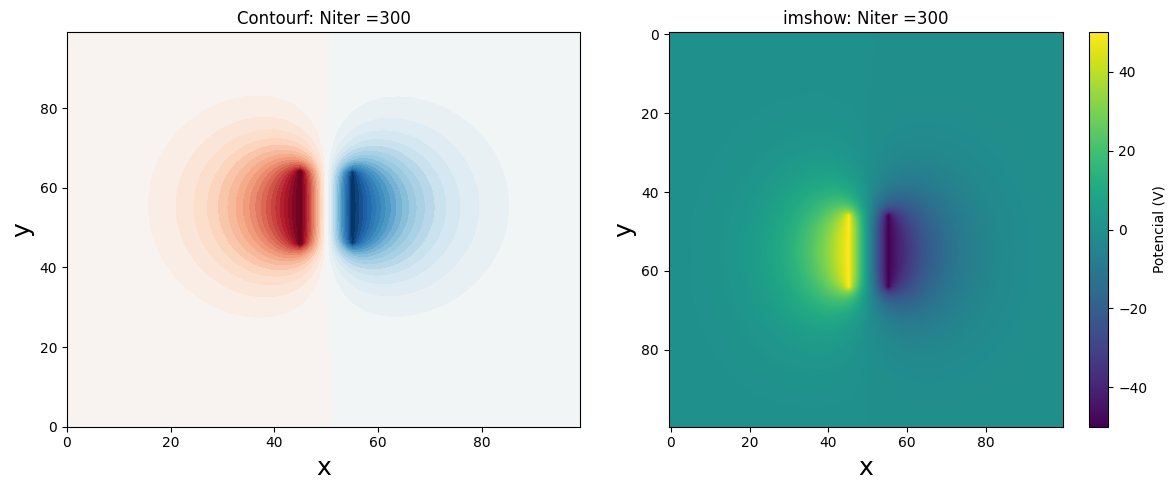

In [5]:
plt.figure(figsize=(10,6))

# Crear figura
fig = plt.figure(figsize=(12,5))

# 🔹 Subplot 1: Superficie 3D
ax1 = fig.add_subplot(1,2,1)
ax1.contourf(V,levels = 40, cmap='RdBu_r')
ax1.set_title('Contourf: Niter =%.1d'%Niter)
ax1.set_xlabel("x",size=18)
ax1.set_ylabel("y",size=18)

# 🔹 Subplot 2: Campo eléctrico 2D
ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(V.copy(), interpolation="bilinear", ) # cmap="hot"


ax2.set_title('imshow: Niter =%.1d'%Niter)
ax2.set_xlabel("x",size=18)
ax2.set_ylabel("y",size=18)

# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')


plt.tight_layout()
plt.show()

# Electric field

Physics tells us that the electric field $\vec{E}$ is the negative gradient of
the potential:

\begin{align}
\vec{E}=& -\nabla U(x,y) = -\dfrac{\partial U(x,y)}{\partial x}\vec{i} - \dfrac{\partial U(x,y)}{\partial y}\vec{j}\,.
\end{align}

Once you have a solution for $U(x, y)$ on a grid, it is simple to use the central-difference approximation for the derivative to determine the field, for example:

\begin{align}
E_x \approx & \dfrac{U(x+\Delta,y) -U(x-\Delta),y}{2\Delta_x} = \dfrac{U_{i+1,j}-U_{i-1,j}}{2\Delta_x}\\
E_y \approx & \dfrac{U(x, y+\Delta) -U(x,y-\Delta)}{2\Delta_y} = \dfrac{U_{i,j+1}-U_{i,j-1}}{2\Delta_y}\,.
\end{align}

Once you have a data file representing such a vector field, it can be visualized by
plotting arrows of varying lengths and directions, or with just lines.

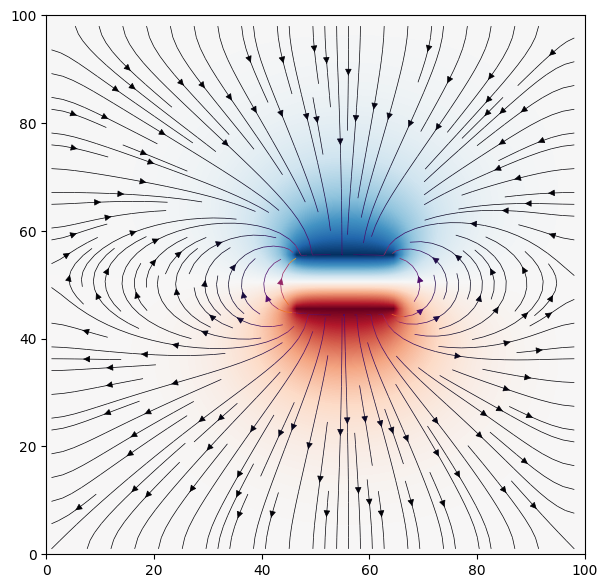

In [ ]:
#***************************************************
#    THIS IS THE CODE TO PLOT THE ELECTRIC FIELD
#***************************************************

U = V.copy()

err = 1e-5
d = 10
l = 20
volt = 50
Nx = 100
Ny = 100
# GRID PARAMETERS
d_grid = d*Nx/100
l_grid = l*Ny/100

# Central derivative for E field
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]
#E[..., 0] es una sintaxis de indexación en NumPy para arrays multidimensionales.

# Interior grid coordinates matching E's shape (Nx-2, Ny-2)
x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(7, 7))

# Background: potential
#ax.imshow(U.T, interpolation="bilinear", extent=[0, Nx, 0, Ny])
ax.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny],interpolation="bilinear")

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()